# Clasificación: bajo peso al nacer

**Objetivo:** predecir si el bebé tendrá **bajo peso al nacer** (variable binaria), ante un conjunto **desbalanceado** (~8% de casos positivos).

**Modelos comparados:** SVM lineal (`LinearSVC`, escalable a muchos registros), **Random Forest** y **XGBoost**.

**Nota:** el archivo de datos es muy grande; para entrenar los tres modelos en tiempo razonable se usa un **muestreo estratificado** fijo (`N_MUESTRA`). Las gráficas de exploración pueden usar una muestra adicional para agilizar el dibujo.


In [1]:
import warnings
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    auc,
    average_precision_score,
    precision_recall_curve,
    classification_report,
    confusion_matrix,
)

try:
    from xgboost import XGBClassifier
except ImportError:
    raise ImportError("Instala xgboost: pip install xgboost")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
warnings.filterwarnings("ignore", category=UserWarning)
sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Carga de datos


In [2]:
FILE_PATH = "peso_bebes.csv"

df = pd.read_csv(FILE_PATH)
print("Dimensiones:", df.shape)
df.head()


Dimensiones: (4255156, 31)


,source_year,year,month,day,wday,state,is_male,child_race,weight_pounds,plurality,apgar_1min,apgar_5min,mother_residence_state,mother_race,mother_age,gestation_weeks,lmp,mother_married,mother_birth_state,cigarette_use,cigarettes_per_day,alcohol_use,drinks_per_week,weight_gain_pounds,born_alive_alive,born_alive_dead,born_dead,ever_born,father_race,father_age,record_weight
0,2022,2022,4,NaN,5,NaN,False,NaN,6.4375,1,NaN,9.0000,NaN,NaN,34,38.0000,7282007,True,NaN,NaN,NaN,NaN,NaN,30.0000,NaN,NaN,NaN,8.0000,NaN,49,1
1,2022,2022,3,NaN,5,NaN,False,NaN,7.2620,1,NaN,9.0000,NaN,NaN,38,40.0000,6102007,True,NaN,NaN,NaN,NaN,NaN,99.0000,NaN,NaN,NaN,8.0000,NaN,45,1
2,2022,2022,12,NaN,2,NaN,True,NaN,6.0010,1,NaN,9.0000,NaN,NaN,30,36.0000,4202008,False,NaN,NaN,NaN,NaN,NaN,54.0000,NaN,NaN,NaN,8.0000,NaN,38,1
3,2022,2022,10,NaN,4,NaN,True,NaN,8.1262,1,NaN,9.0000,NaN,NaN,31,38.0000,2052008,False,NaN,NaN,NaN,NaN,NaN,30.0000,NaN,NaN,NaN,8.0000,NaN,39,1
4,2022,2022,11,NaN,4,NaN,False,NaN,7.3127,1,NaN,9.0000,NaN,NaN,39,39.0000,2082008,True,NaN,NaN,NaN,NaN,NaN,10.0000,NaN,NaN,NaN,8.0000,NaN,40,1


## 2. Definición explícita de variables

### Variable objetivo (lo que predecimos)

- **`bajo_peso`**: se define como **1** si `weight_pounds` **< 5.5 libras** (aprox. 2495 g; criterio habitual en datos de natalidad tipo US), y **0** en caso contrario.

### Variables predictoras (features) — las que entran al modelo

Se usan **12 columnas** del CSV; **no** se usa el peso como entrada (el peso solo sirve para construir la etiqueta).

| Variable | Tipo | Descripción breve |
|----------|------|-------------------|
| `month` | numérica | Mes |
| `wday` | numérica | Día de la semana |
| `is_male` | categórica | Sexo del bebé |
| `plurality` | numérica | Número de fetos / orden |
| `mother_age` | numérica | Edad de la madre |
| `gestation_weeks` | numérica | Semanas de gestación |
| `lmp` | numérica | Código/fecha LMP |
| `mother_married` | categórica | Estado civil |
| `cigarette_use` | categórica | Uso de cigarrillo |
| `weight_gain_pounds` | numérica | Aumento de peso materno (lb) |
| `ever_born` | numérica | Hijos previos / paridad |
| `father_age` | numérica | Edad del padre |

*(La variable `weight_pounds` solo define el target y se excluye de X.)*


In [3]:
# --- Umbral bajo peso (libras) ---
THRESHOLD_LB = 5.5

FEATURE_COLUMNS = [
    "month",
    "wday",
    "is_male",
    "plurality",
    "mother_age",
    "gestation_weeks",
    "lmp",
    "mother_married",
    "cigarette_use",
    "weight_gain_pounds",
    "ever_born",
    "father_age",
]

TARGET_COL = "weight_pounds"
LABEL_NAME = "bajo_peso"

model_df = df[FEATURE_COLUMNS + [TARGET_COL]].copy()
model_df = model_df.dropna(subset=[TARGET_COL])

model_df[LABEL_NAME] = (model_df[TARGET_COL] < THRESHOLD_LB).astype(int)
prop = model_df[LABEL_NAME].mean()
print(f"Proporción bajo peso (clase 1): {prop:.2%}")
print(model_df[LABEL_NAME].value_counts())


Proporción bajo peso (clase 1): 7.89%
bajo_peso
0    3915606
1     335185
Name: count, dtype: int64


### Valores faltantes (NA)

**Qué se hace en este flujo:**

- **Solo se eliminan filas** donde falta **`weight_pounds`**, porque sin peso no se puede definir `bajo_peso`.
- En las **variables predictoras**, los NA **no** implican borrar la fila completa: dentro del pipeline se **imputan** — **mediana** en numéricas y **valor más frecuente (moda)** en categóricas (`SimpleImputer`).
- **No** se descartó ninguna variable automáticamente por tener muchos faltantes (por ejemplo `cigarette_use` suele tener un porcentaje alto de NA en estos datos). La celda siguiente muestra el `%` de faltantes por columna; si quieres excluir columnas por umbral, puedes activar el bloque opcional.

In [4]:
# Porcentaje de NA por variable predictora (tras quitar solo filas sin peso)
missing_pct = (model_df[FEATURE_COLUMNS].isna().mean() * 100).sort_values(ascending=False)
display(missing_pct.to_frame("missing_%"))

# --- Opcional: quitar predictoras con demasiados faltantes ---
# Ejecuta solo si quieres este criterio; luego re-ejecuta las celdas siguientes hasta el final.
# MAX_MISSING_PCT = 70
# to_drop = missing_pct[missing_pct > MAX_MISSING_PCT].index.tolist()
# if to_drop:
#     print("Excluidas por faltantes >", MAX_MISSING_PCT, "%:", to_drop)
#     FEATURE_COLUMNS = [c for c in FEATURE_COLUMNS if c not in to_drop]
#     model_df = df[FEATURE_COLUMNS + [TARGET_COL]].copy()
#     model_df = model_df.dropna(subset=[TARGET_COL])
#     model_df[LABEL_NAME] = (model_df[TARGET_COL] < THRESHOLD_LB).astype(int)

,missing_%
cigarette_use,65.0091
weight_gain_pounds,2.2293
ever_born,0.6058
gestation_weeks,0.1140
plurality,0.0000
is_male,0.0000
wday,0.0000
month,0.0000
mother_married,0.0000
lmp,0.0000


## 3. Exploración de variables (gráficas)


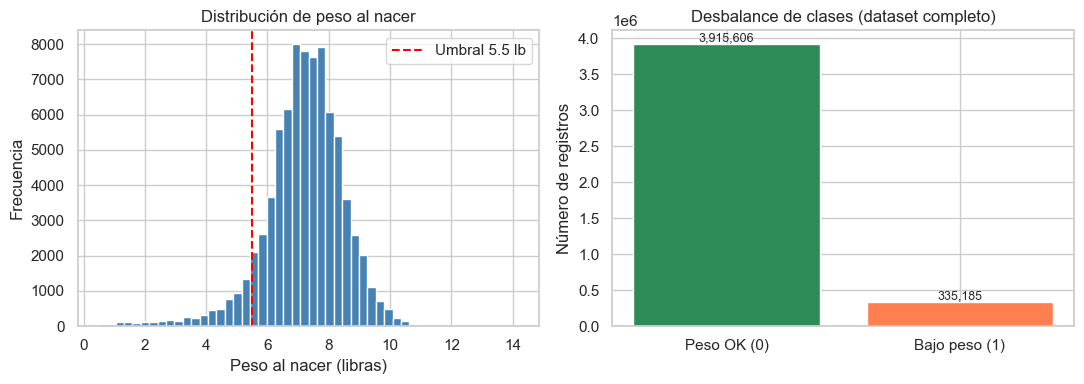

In [5]:
# Muestra para gráficas (evita bloquear el notebook con millones de puntos)
N_PLOT = min(80_000, len(model_df))
plot_df = model_df.sample(n=N_PLOT, random_state=RANDOM_STATE)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
plot_df[TARGET_COL].hist(bins=50, ax=ax[0], color="steelblue", edgecolor="white")
ax[0].axvline(THRESHOLD_LB, color="red", linestyle="--", label=f"Umbral {THRESHOLD_LB} lb")
ax[0].set_xlabel("Peso al nacer (libras)")
ax[0].set_ylabel("Frecuencia")
ax[0].set_title("Distribución de peso al nacer")
ax[0].legend()

balance = model_df[LABEL_NAME].value_counts().sort_index()
ax[1].bar(["Peso OK (0)", "Bajo peso (1)"], balance.values, color=["seagreen", "coral"])
ax[1].set_ylabel("Número de registros")
ax[1].set_title("Desbalance de clases (dataset completo)")
for i, v in enumerate(balance.values):
    ax[1].text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()


C:\Users\jhonn\AppData\Local\Temp\ipykernel_22152\848008968.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=LABEL_NAME, y=col, ax=axes[i], palette="Set2")
C:\Users\jhonn\AppData\Local\Temp\ipykernel_22152\848008968.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=LABEL_NAME, y=col, ax=axes[i], palette="Set2")
C:\Users\jhonn\AppData\Local\Temp\ipykernel_22152\848008968.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x=LABEL_NAME, y=col, ax=axes[i], palette="Set2")
C:\Users\jhonn\AppD

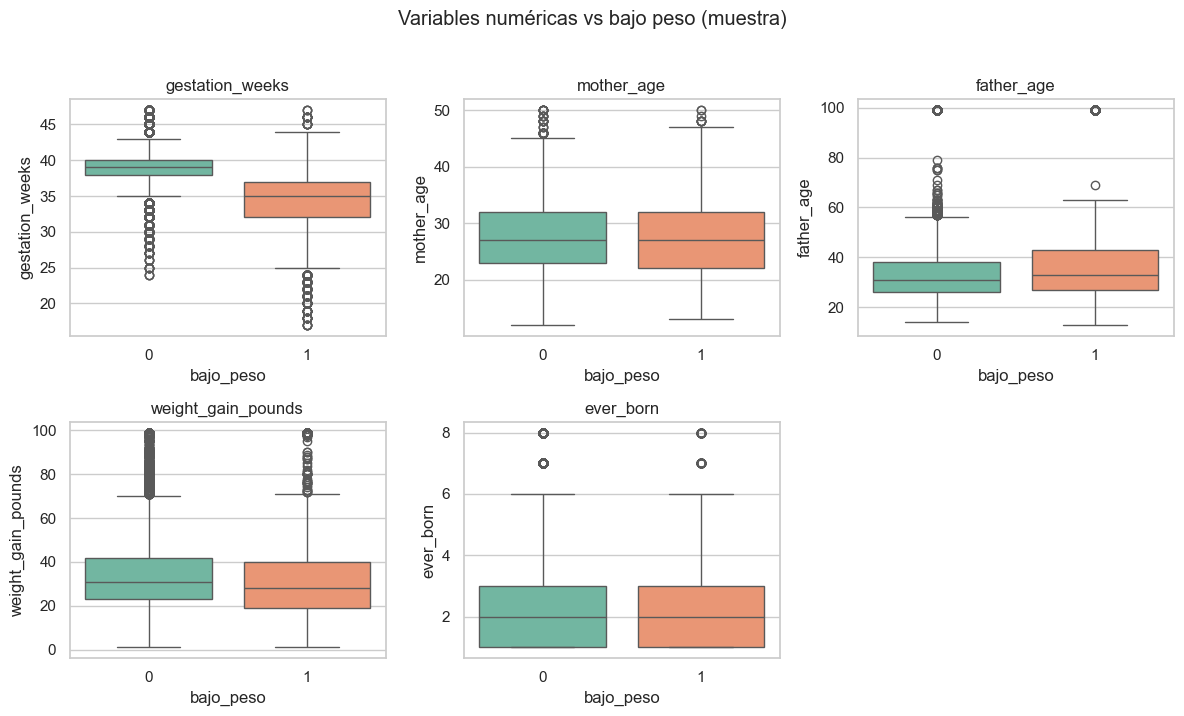

In [6]:
# Boxplots de variables numéricas clave según clase
num_cols_plot = [
    "gestation_weeks",
    "mother_age",
    "father_age",
    "weight_gain_pounds",
    "ever_born",
]
fig, axes = plt.subplots(2, 3, figsize=(12, 7))
axes = axes.ravel()
for i, col in enumerate(num_cols_plot):
    sns.boxplot(data=plot_df, x=LABEL_NAME, y=col, ax=axes[i], palette="Set2")
    axes[i].set_title(col)
axes[5].axis("off")
plt.suptitle("Variables numéricas vs bajo peso (muestra)", y=1.02)
plt.tight_layout()
plt.show()


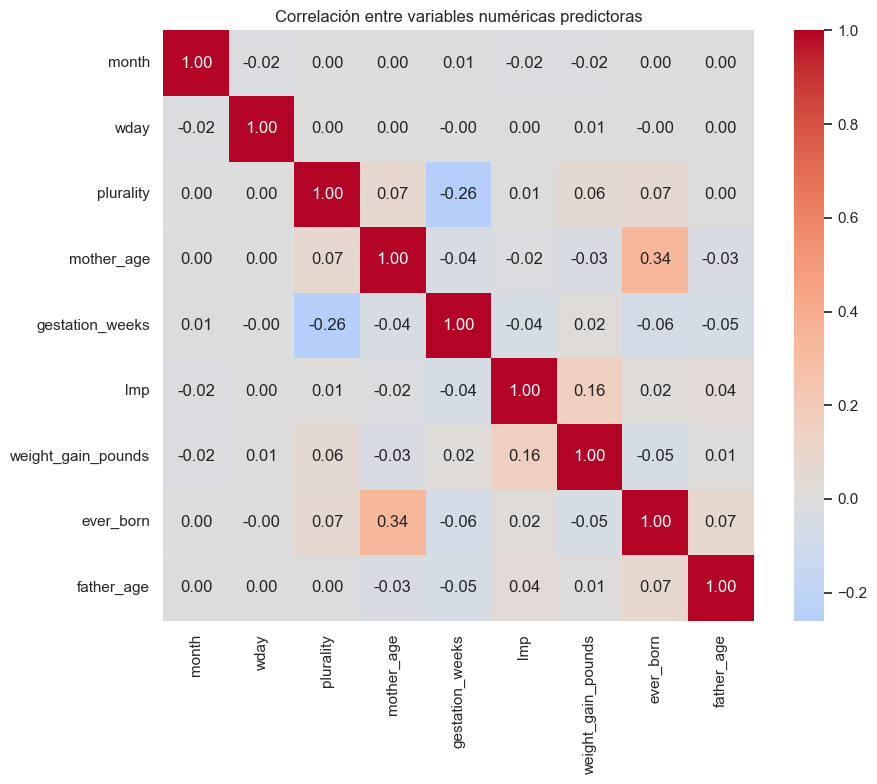

In [7]:
# Matriz de correlación (solo numéricas de las features)
num_for_corr = [
    c
    for c in FEATURE_COLUMNS
    if model_df[c].dtype in ("float64", "int64", "float32", "int32")
]
corr = model_df[num_for_corr].corr(numeric_only=True)
plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlación entre variables numéricas predictoras")
plt.tight_layout()
plt.show()


## 4. Preparación del dataset y división train / test

- Se eliminan filas con `weight_pounds` faltante (ya hecho). El resto de NA en predictoras se **imputa** en el pipeline (mediana / moda), no se borran filas por ese motivo.
- Para **entrenar** los modelos en tiempo razonable se toma una **muestra estratificada** de `N_MUESTRA` filas (mantiene ~8% de positivos).
- **Train/test 80/20** con `stratify` sobre `bajo_peso`.
- **Desbalance:** `class_weight='balanced'` en SVM y Random Forest; en XGBoost se usa `scale_pos_weight = n_negativos / n_positivos`.


In [8]:
from sklearn.model_selection import train_test_split

N_MUESTRA = 250_000  # ajusta si necesitas más datos (más lento)

if len(model_df) > N_MUESTRA:
    model_sample, _ = train_test_split(
        model_df,
        train_size=N_MUESTRA,
        random_state=RANDOM_STATE,
        stratify=model_df[LABEL_NAME]
    )
    print(f"Muestra estratificada para modelado: {len(model_sample):,} filas")
else:
    model_sample = model_df.copy()
    print(f"Usando todas las filas: {len(model_sample):,}")

X = model_sample[FEATURE_COLUMNS]
y = model_sample[LABEL_NAME]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train:", X_train.shape, "| Test:", X_test.shape)
print("Proporción clase 1 en train:", y_train.mean())
print("Proporción clase 1 en test :", y_test.mean())

# Para XGBoost: peso de la clase positiva
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
scale_pos_weight = n_neg / max(n_pos, 1)
print("scale_pos_weight (XGBoost):", round(scale_pos_weight, 2))


Muestra estratificada para modelado: 250,000 filas
Train: (200000, 12) | Test: (50000, 12)
Proporción clase 1 en train: 0.07885
Proporción clase 1 en test : 0.07886
scale_pos_weight (XGBoost): 11.68


In [9]:
categorical_cols = ["is_male", "mother_married", "cigarette_use"]
numeric_cols = [c for c in FEATURE_COLUMNS if c not in categorical_cols]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)


## 5. Métricas que usamos para comparar

| Métrica | Qué mide |
|---------|----------|
| **Accuracy** | Proporción de aciertos globales (puede ser engañosa con desbalance). |
| **Precision (clase bajo peso)** | De los predichos como bajo peso, cuántos realmente lo son. |
| **Recall (clase bajo peso)** | De los verdaderos bajo peso, cuántos detecta el modelo. |
| **F1** | Media armónica de precision y recall (equilibrio). |
| **ROC-AUC** | Capacidad de discriminar entre clases usando scores/probabilidades. |
| **PR-AUC** (average precision) | Muy útil cuando la clase positiva es minoritaria. |

**Criterio para elegir “mejor” modelo:** en problemas de salud con clase minoritaria suele priorizarse **recall** o **F1** de la clase positiva, y **PR-AUC**; reportamos todas y destacamos el ganador por **ROC-AUC** y por **F1** (clase 1).

**Dónde se evalúa el conjunto de prueba (test):** en la celda de `train_test_split` se crean **`X_test`** y **`y_test`** (20% de la muestra de modelado, estratificada). Todas las predicciones `*_predict(X_test)` y la función `evaluar_modelo(..., y_test, ...)` usan ese test. La tabla de comparación, las **curvas ROC/PR** y los **reportes/matrices de confusión** posteriores se calculan **solo sobre test**, no sobre train.


In [10]:
def evaluar_modelo(nombre, y_true, y_pred, y_score):
    out = {
        "modelo": nombre,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision_bajo_peso": precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        "recall_bajo_peso": recall_score(y_true, y_pred, pos_label=1, zero_division=0),
        "f1_bajo_peso": f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_score),
        "pr_auc": average_precision_score(y_true, y_score),
    }
    return out


resultados = []


In [11]:
# --- 1) SVM lineal (LinearSVC) — escalable; scores para ROC-AUC ---
svm_pipe = Pipeline(
    steps=[
        ("prep", clone(preprocessor)),
        (
            "clf",
            LinearSVC(
                class_weight="balanced",
                random_state=RANDOM_STATE,
                dual=False,
                max_iter=3000,
            ),
        ),
    ]
)
svm_pipe.fit(X_train, y_train)
y_pred_svm = svm_pipe.predict(X_test)
y_score_svm = svm_pipe.decision_function(X_test)
resultados.append(evaluar_modelo("SVM (LinearSVC)", y_test, y_pred_svm, y_score_svm))


In [12]:
# --- 2) Random Forest ---
rf_pipe = Pipeline(
    steps=[
        ("prep", clone(preprocessor)),
        (
            "clf",
            RandomForestClassifier(
                n_estimators=200,
                class_weight="balanced",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                max_depth=20,
            ),
        ),
    ]
)
rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_score_rf = rf_pipe.predict_proba(X_test)[:, 1]
resultados.append(evaluar_modelo("Random Forest", y_test, y_pred_rf, y_score_rf))


In [13]:
# --- 3) XGBoost (usa el mismo preprocessor; entrada densa) ---
xgb_pipe = Pipeline(
    steps=[
        ("prep", clone(preprocessor)),
        (
            "clf",
            XGBClassifier(
                n_estimators=200,
                max_depth=8,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                eval_metric="logloss",
            ),
        ),
    ]
)
xgb_pipe.fit(X_train, y_train)
y_pred_xgb = xgb_pipe.predict(X_test)
y_score_xgb = xgb_pipe.predict_proba(X_test)[:, 1]
resultados.append(evaluar_modelo("XGBoost", y_test, y_pred_xgb, y_score_xgb))


In [14]:
tabla = pd.DataFrame(resultados)
tabla = tabla.sort_values("roc_auc", ascending=False)
print("=== Comparación de modelos (conjunto de prueba) ===")
display(tabla)

best_roc = tabla.iloc[0]["modelo"]
best_f1 = tabla.sort_values("f1_bajo_peso", ascending=False).iloc[0]["modelo"]

print("\n--- Conclusión explícita ---")
print(f"Mayor ROC-AUC: {best_roc}")
print(f"Mayor F1 (clase bajo peso): {best_f1}")
if best_roc == best_f1:
    print(f"\n**Mejor modelo global según estos criterios:** {best_roc}")
else:
    print(
        "\nSi priorizas discriminar entre clases (ROC-AUC), elige:",
        best_roc,
        "| Si priorizas equilibrio precisión-recall en positivos (F1), elige:",
        best_f1,
    )


=== Comparación de modelos (conjunto de prueba) ===


,modelo,accuracy,precision_bajo_peso,recall_bajo_peso,f1_bajo_peso,roc_auc,pr_auc
0,SVM (LinearSVC),0.8829,0.3777,0.7494,0.5023,0.8868,0.6103
2,XGBoost,0.8855,0.3818,0.7299,0.5014,0.8866,0.6139
1,Random Forest,0.9378,0.6342,0.4981,0.5580,0.8785,0.5861



--- Conclusión explícita ---
Mayor ROC-AUC: SVM (LinearSVC)
Mayor F1 (clase bajo peso): Random Forest

Si priorizas discriminar entre clases (ROC-AUC), elige: SVM (LinearSVC) | Si priorizas equilibrio precisión-recall en positivos (F1), elige: Random Forest


### Curvas ROC y Precision-Recall (solo **conjunto de prueba / test**)

Las siguientes figuras usan **`y_test`** y los scores/probabilidades predichas sobre **`X_test`** (la misma partición 20% estratificada definida arriba). La ROC compara la capacidad de discriminar clases; la curva PR es muy útil con clases desbalanceadas.

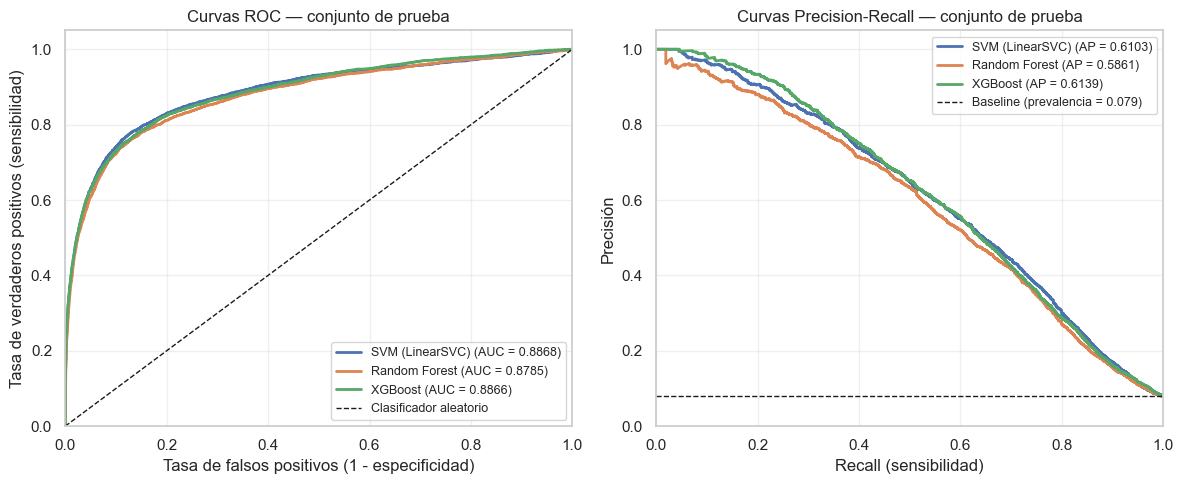

In [17]:
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

# =========================================================
# IMPORTANTE:
# y_score_* debe ser score continuo, no predicción 0/1
# Ejemplos:
# y_score_svm = svm_model.decision_function(X_test)
# y_score_rf  = rf_model.predict_proba(X_test)[:, 1]
# y_score_xgb = xgb_model.predict_proba(X_test)[:, 1]
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

curvas = [
    ("SVM (LinearSVC)", y_score_svm),
    ("Random Forest", y_score_rf),
    ("XGBoost", y_score_xgb),
]

# -------------------------
# Curvas ROC
# -------------------------
for nombre, y_score in curvas:
    fpr, tpr, _ = roc_curve(y_test, y_score)
    roc_auc = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, lw=2, label=f"{nombre} (AUC = {roc_auc:.4f})")

axes[0].plot([0, 1], [0, 1], "k--", lw=1, label="Clasificador aleatorio")
axes[0].set_xlabel("Tasa de falsos positivos (1 - especificidad)")
axes[0].set_ylabel("Tasa de verdaderos positivos (sensibilidad)")
axes[0].set_title("Curvas ROC — conjunto de prueba")
axes[0].legend(loc="lower right", fontsize=9)
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1.05)
axes[0].grid(True, alpha=0.3)

# -------------------------
# Curvas Precision-Recall
# -------------------------
baseline = y_test.mean()

for nombre, y_score in curvas:
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    ap = average_precision_score(y_test, y_score)
    axes[1].plot(recall, precision, lw=2, label=f"{nombre} (AP = {ap:.4f})")

axes[1].axhline(
    baseline,
    color="k",
    linestyle="--",
    lw=1,
    label=f"Baseline (prevalencia = {baseline:.3f})"
)

axes[1].set_xlabel("Recall (sensibilidad)")
axes[1].set_ylabel("Precisión")
axes[1].set_title("Curvas Precision-Recall — conjunto de prueba")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [15]:
# Reporte y matrices de confusión por modelo
for nombre, pipe, y_pred in [
    ("SVM", svm_pipe, y_pred_svm),
    ("Random Forest", rf_pipe, y_pred_rf),
    ("XGBoost", xgb_pipe, y_pred_xgb),
]:
    print("=" * 60, nombre, "=" * 60)
    print(classification_report(y_test, y_pred, target_names=["peso OK", "bajo peso"]))
    print("Matriz [ [TN FP] [FN TP] ]:")
    print(confusion_matrix(y_test, y_pred))


============================================================ SVM ============================================================
              precision    recall  f1-score   support

     peso OK       0.98      0.89      0.93     46057
   bajo peso       0.38      0.75      0.50      3943

    accuracy                           0.88     50000
   macro avg       0.68      0.82      0.72     50000
weighted avg       0.93      0.88      0.90     50000

Matriz [ [TN FP] [FN TP] ]:
[[41189  4868]
 [  988  2955]]
============================================================ Random Forest ============================================================
              precision    recall  f1-score   support

     peso OK       0.96      0.98      0.97     46057
   bajo peso       0.63      0.50      0.56      3943

    accuracy                           0.94     50000
   macro avg       0.80      0.74      0.76     50000
weighted avg       0.93      0.94      0.93     50000

Matriz [ [TN FP] [FN TP] 

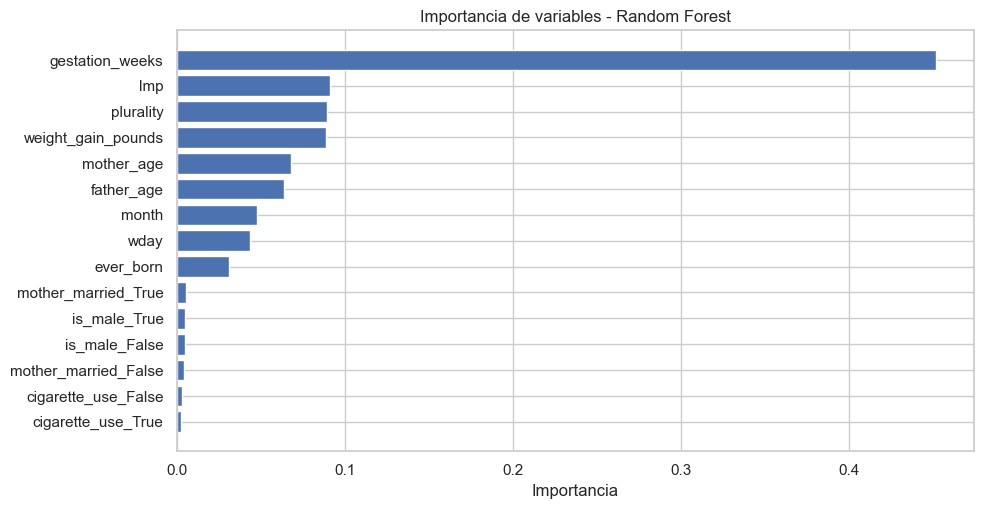

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# Extraer nombres de features tras el preprocesamiento
rf_clf = rf_pipe.named_steps["clf"]
prep_fit = rf_pipe.named_steps["prep"]

categorical_cols = ["is_male", "mother_married", "cigarette_use"]
numeric_cols_local = [c for c in FEATURE_COLUMNS if c not in categorical_cols]

# Nombres después del OneHotEncoder
ohe = prep_fit.named_transformers_["cat"].named_steps["onehot"]
cat_names = ohe.get_feature_names_out(categorical_cols).tolist()

feature_names = numeric_cols_local + cat_names
importances = rf_clf.feature_importances_

# Ordenar
idx = np.argsort(importances)
feat_sorted = [feature_names[i] for i in idx]
imp_sorted = importances[idx]

# Gráfica simple
plt.figure(figsize=(10, max(5, len(feat_sorted) * 0.35)))
plt.barh(feat_sorted, imp_sorted)
plt.xlabel("Importancia")
plt.title("Importancia de variables - Random Forest")
plt.tight_layout()
plt.show()